# Qualidade dos dados — NHAMCS Emergency Department 2021

**FIAP Tech Challenge Fase 3 — Hospital Triage**

Este notebook valida a matéria-prima antes da exploração clínica. Ele
verifica versão, schema, volume, duplicidade, códigos especiais,
domínios, elegibilidade do target, cobertura dos motivos da visita e
separação entre campos de entrada e informações pós-triagem.

Fontes oficiais:

- [NHAMCS-ED 2021 — dados e documentação](https://www.cdc.gov/nchs/nhamcs/documentation/about-the-data-2021.html);
- [Documentação técnica e codebook](https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/doc21-ed-508.pdf);
- [Descrições ICD-10-CM 2021](https://www.cms.gov/medicare/coding-billing/ICD-10-codes);
- [NCHS Data User Agreement](https://www.cdc.gov/nchs/policy/data-user-agreement.html).

> Aprovação neste notebook significa adequação técnica para a EDA e
> para a futura preparação dos dados. Não representa validação clínica
> para uso assistencial.

## 1. Contrato de qualidade

Os controles são classificados como **gates**: qualquer falha interrompe
a execução. Ausência de informação clínica, por outro lado, é medida e
documentada; ela não é automaticamente tratada como erro.

Critérios principais:

- arquivos e hashes correspondem à versão aprovada;
- o arquivo possui 16.207 linhas, 912 colunas e o schema mínimo;
- não há visitas duplicadas pela chave técnica pública;
- códigos sentinela são separados de valores utilizáveis;
- `IMMEDR` gera exatamente a coorte elegível esperada;
- códigos `RFV1`–`RFV5` positivos possuem descrição oficial;
- sinais vitais respeitam domínios de representação após remover
  sentinelas;
- campos pós-atendimento não se misturam às entradas permitidas.

In [1]:
from pathlib import Path
import hashlib
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from pandas.io.stata import StataReader

plt.style.use("ggplot")
pd.set_option("display.max_columns", 50)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (
            candidate / "docs"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto."
    )


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(
            lambda: file_handle.read(1024 * 1024), b""
        ):
            digest.update(chunk)
    return digest.hexdigest()


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "nhamcs"
    / "2021"
    / "ed2021-stata.dta"
)
ICD10CM_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "references"
    / "icd10cm"
    / "2021"
    / "icd10cm_order_2021.txt"
)
EXPECTED_SHA256 = {
    DATA_PATH: (
        "c1438773d451c78652bf371fc369da5281aa2c82eb5983cccc2646b66d218038"
    ),
    ICD10CM_PATH: (
        "024c8cdaab815c987f3d43544758047992ef7b5677c92369b1a04ac69b83b48c"
    ),
}
EDA_DATABASE_PATH = (
    PROJECT_ROOT / "data" / "processed" / "nhamcs_2021_eda.db"
)
EXPECTED_SHAPE = (16_207, 912)
RFV_COLUMNS = [f"RFV{index}" for index in range(1, 6)]
DIAGNOSIS_COLUMNS = [f"DIAG{index}" for index in range(1, 6)]
TARGET_MAP = {
    1: "urgente",
    2: "urgente",
    3: "atencao",
    4: "normal",
    5: "normal",
}
TARGET_ORDER = ["normal", "atencao", "urgente"]
REQUIRED_COLUMNS = {
    "HOSPCODE",
    "PATCODE",
    "YEAR",
    "AGE",
    "AGEDAYS",
    "SEX",
    "IMMEDR",
    *RFV_COLUMNS,
    "TEMPF",
    "PULSE",
    "RESPR",
    "BPSYS",
    "BPDIAS",
    "POPCT",
    "PAINSCALE",
    "DIAG1",
    "ADMITHOS",
    "OBSHOS",
    "ADMIT",
    "DIEDED",
}

missing_files = [
    str(path) for path in EXPECTED_SHA256 if not path.exists()
]
if missing_files:
    raise FileNotFoundError(
        "Arquivos ausentes. Execute `python data/download_dataset.py`: "
        + ", ".join(missing_files)
    )

PROJECT_ROOT

PosixPath('/Users/cassiojr/FIAP/Tech Challenge 3')

## 2. Proveniência e integridade binária

Os hashes evitam analisar silenciosamente outra versão dos dados ou da
referência ICD-10-CM.

In [2]:
integrity_records = []
for path, expected_hash in EXPECTED_SHA256.items():
    actual_hash = sha256(path)
    integrity_records.append(
        {
            "file": path.name,
            "size_mb": path.stat().st_size / 1024**2,
            "expected_sha256": expected_hash,
            "actual_sha256": actual_hash,
            "valid": actual_hash == expected_hash,
        }
    )

integrity = pd.DataFrame(integrity_records)
data_integrity_ok = bool(integrity["valid"].all())
assert data_integrity_ok, (
    "Um arquivo não corresponde à versão esperada."
)
display(integrity.style.format({"size_mb": "{:.2f}"}))

,file,size_mb,expected_sha256,actual_sha256,valid
0,ed2021-stata.dta,36.38,c1438773d451c78652bf371fc369da5281aa2c82eb5983cccc2646b66d218038,c1438773d451c78652bf371fc369da5281aa2c82eb5983cccc2646b66d218038,True
1,icd10cm_order_2021.txt,13.60,024c8cdaab815c987f3d43544758047992ef7b5677c92369b1a04ac69b83b48c,024c8cdaab815c987f3d43544758047992ef7b5677c92369b1a04ac69b83b48c,True


## 3. Schema, volume e tipos

O contrato fixa a versão pública de 2021. Colunas adicionais são
permitidas em futuras adaptações, mas nenhuma coluna obrigatória pode
desaparecer.

In [3]:
stata_reader = StataReader(
    DATA_PATH,
    convert_categoricals=False,
)
stata_labels = stata_reader.value_labels()
variable_labels = stata_reader.variable_labels()
raw = pd.read_stata(DATA_PATH, convert_categoricals=False)

missing_required_columns = sorted(
    REQUIRED_COLUMNS.difference(raw.columns)
)
shape_ok = raw.shape == EXPECTED_SHAPE

schema = pd.DataFrame(
    [
        {
            "column": column,
            "dtype": str(raw[column].dtype),
            "direct_nulls": int(raw[column].isna().sum()),
            "description": variable_labels.get(column, ""),
        }
        for column in sorted(REQUIRED_COLUMNS.intersection(raw.columns))
    ]
)

assert not missing_required_columns, (
    f"Colunas obrigatórias ausentes: {missing_required_columns}"
)
assert shape_ok, (
    f"Shape inesperado: {raw.shape}; esperado: {EXPECTED_SHAPE}."
)

print(f"Shape validado: {raw.shape}")
display(schema)

Shape validado: (16207, 912)


,column,dtype,direct_nulls,description
0,ADMIT,int16,0,Admitted to:
1,ADMITHOS,int8,0,Admit to this hospital
2,AGE,int16,0,Patient age in years
3,AGEDAYS,int16,0,Age in days for patients less than one year
4,BPDIAS,int16,0,Initial vital signs: Blood pressure - Diastolic
5,BPSYS,int16,0,Initial vital signs: Blood pressure - Systolic
6,DIAG1,object,0,Diagnosis #1
7,DIEDED,int8,0,Died in ED
8,HOSPCODE,int16,0,Hospital number
9,IMMEDR,int16,0,Immediacy with which patient should be seen (u...


## 4. Unidade de análise e duplicidade

O arquivo não fornece um `CASEID`. A combinação pública `HOSPCODE` +
`PATCODE` é usada apenas como chave técnica para verificar uma linha por
atendimento; ela não será feature e não deve ser usada para tentar
identificar paciente ou instituição.

In [4]:
exact_duplicate_rows = int(raw.duplicated().sum())
technical_key = ["HOSPCODE", "PATCODE"]
missing_technical_keys = int(
    raw[technical_key].isna().any(axis=1).sum()
)
duplicated_technical_keys = int(
    raw.duplicated(technical_key).sum()
)

uniqueness = pd.DataFrame(
    [
        {
            "check": "Exact duplicate rows",
            "rows": exact_duplicate_rows,
        },
        {
            "check": "Missing technical key",
            "rows": missing_technical_keys,
        },
        {
            "check": "Duplicated technical key",
            "rows": duplicated_technical_keys,
        },
    ]
)
display(uniqueness)

assert exact_duplicate_rows == 0
assert missing_technical_keys == 0
assert duplicated_technical_keys == 0

,check,rows
0,Exact duplicate rows,0
1,Missing technical key,0
2,Duplicated technical key,0


## 5. Nulos reais versus códigos especiais

O arquivo Stata possui poucos `NaN` porque ausência e inaplicabilidade
são codificadas com valores como `-9`, `-8`, `-7` e `998`. Esses valores
precisam ser convertidos explicitamente; tratá-los como medições
produziria estatísticas e modelos incorretos.

In [5]:
SPECIAL_CODES = {
    "IMMEDR": {-9, -8, 0, 7},
    "AGEDAYS": {-7},
    "RFV1": {-9},
    "RFV2": {-9},
    "RFV3": {-9},
    "RFV4": {-9},
    "RFV5": {-9},
    "TEMPF": {-9},
    "PULSE": {-9, 998},
    "RESPR": {-9},
    "BPSYS": {-9},
    "BPDIAS": {-9, 998},
    "POPCT": {-9},
    "PAINSCALE": {-9, -8},
}

encoded_missingness = pd.DataFrame(
    [
        {
            "field": column,
            "direct_nulls": int(raw[column].isna().sum()),
            "special_rows": int(
                raw[column].isin(special_codes).sum()
            ),
            "usable_rows": int(
                (~raw[column].isin(special_codes)).sum()
            ),
            "usable_rate": (
                ~raw[column].isin(special_codes)
            ).mean(),
        }
        for column, special_codes in SPECIAL_CODES.items()
    ]
)
display(
    encoded_missingness.style.format(
        {"usable_rate": "{:.1%}"}
    )
)

,field,direct_nulls,special_rows,usable_rows,usable_rate
0,IMMEDR,0,5712,10495,64.8%
1,AGEDAYS,0,15839,368,2.3%
2,RFV1,0,17,16190,99.9%
3,RFV2,0,5640,10567,65.2%
4,RFV3,0,9745,6462,39.9%
5,RFV4,0,12532,3675,22.7%
6,RFV5,0,14148,2059,12.7%
7,TEMPF,0,1045,15162,93.6%
8,PULSE,0,897,15310,94.5%
9,RESPR,0,881,15326,94.6%


## 6. Elegibilidade e qualidade do target

`IMMEDR` aceita nove estados no arquivo original. Somente 1 a 5
representam níveis observados de prioridade e entram na modelagem.
Branco, desconhecido, ausência de triagem e unidades sem triagem são
exclusões justificadas, não classes clínicas.

In [6]:
immediacy_lookup = {
    int(code): label
    for code, label in stata_labels["IMMEDRF"].items()
}
source_target_domain_ok = set(raw["IMMEDR"].unique()).issubset(
    immediacy_lookup
)

eligibility = (
    raw["IMMEDR"]
    .map(immediacy_lookup)
    .value_counts(dropna=False)
    .rename_axis("source_triage")
    .rename("rows")
    .reset_index()
)
eligibility["eligible"] = eligibility["source_triage"].isin(
    [
        "Immediate",
        "Emergent",
        "Urgent",
        "Semi-urgent",
        "Nonurgent",
    ]
)
display(eligibility)

eligible = raw.loc[raw["IMMEDR"].isin(TARGET_MAP)].copy()
eligible["target"] = pd.Categorical(
    eligible["IMMEDR"].map(TARGET_MAP),
    categories=TARGET_ORDER,
    ordered=True,
)
target_distribution = (
    eligible["target"]
    .value_counts(sort=False)
    .rename("rows")
    .to_frame()
)
target_distribution["rate"] = (
    target_distribution["rows"] / len(eligible)
)
display(
    target_distribution.style.format({"rate": "{:.2%}"})
)

assert source_target_domain_ok
assert len(eligible) == 10_495
assert eligible["target"].nunique() == 3

,source_triage,rows,eligible
0,Urgent,5429,True
1,Unknown,3844,False
2,Semi-urgent,2767,True
3,Emergent,1651,True
4,Visit occurred in ESA that does not conduct nu...,792,False
5,Blank,632,False
6,No triage for this visit but ESA does conduct ...,444,False
7,Nonurgent,419,True
8,Immediate,229,True


,rows,rate
target,,
normal,3186,30.36%
atencao,5429,51.73%
urgente,1880,17.91%


## 7. Demografia e motivos da visita

Para idade, `93` significa “93 anos ou mais” e `AGEDAYS=-7` significa
“um ano ou mais”. Nos motivos da visita, `-9` é ausência; todo código
positivo deve existir no dicionário oficial `RFVF`.

In [7]:
age_domain_ok = bool(raw["AGE"].between(0, 93).all())
age_days_consistent = bool(
    (
        raw["AGE"].eq(0)
        & raw["AGEDAYS"].between(0, 365)
    ).sum()
    + (
        raw["AGE"].ge(1) & raw["AGEDAYS"].eq(-7)
    ).sum()
    == len(raw)
)
sex_domain_ok = set(raw["SEX"].unique()).issubset({1, 2})

demographic_checks = pd.DataFrame(
    [
        {
            "check": "AGE within 0..93",
            "valid": age_domain_ok,
        },
        {
            "check": "AGE and AGEDAYS consistent",
            "valid": age_days_consistent,
        },
        {
            "check": "SEX within official domain",
            "valid": sex_domain_ok,
        },
    ]
)
display(demographic_checks)

rfv_lookup = {
    int(code): label
    for code, label in stata_labels["RFVF"].items()
    if int(code) > 0
}
rfv_audit = pd.DataFrame(
    [
        {
            "field": column,
            "positive_codes": int(raw[column].gt(0).sum()),
            "blank_rows": int(raw[column].eq(-9).sum()),
            "unmapped_positive_rows": int(
                (
                    raw[column].gt(0)
                    & ~raw[column].isin(rfv_lookup)
                ).sum()
            ),
        }
        for column in RFV_COLUMNS
    ]
)
primary_rfv_coverage = eligible["RFV1"].gt(0).mean()
unmapped_rfv_rows = int(
    rfv_audit["unmapped_positive_rows"].sum()
)
display(rfv_audit)
print(
    "Cobertura de RFV1 na coorte elegível: "
    f"{primary_rfv_coverage:.2%}"
)

assert demographic_checks["valid"].all()
assert unmapped_rfv_rows == 0
assert primary_rfv_coverage >= 0.95

,check,valid
0,AGE within 0..93,True
1,AGE and AGEDAYS consistent,True
2,SEX within official domain,True


,field,positive_codes,blank_rows,unmapped_positive_rows
0,RFV1,16190,17,0
1,RFV2,10567,5640,0
2,RFV3,6462,9745,0
3,RFV4,3675,12532,0
4,RFV5,2059,14148,0


Cobertura de RFV1 na coorte elegível: 99.97%


## 8. Domínios e completude dos sinais de triagem

As faixas abaixo validam a **representação numérica**, não classificam
um paciente como normal ou anormal. Valores clínicos extremos são
preservados. Somente sentinelas oficiais e valores fora do domínio de
representação são convertidos em ausência.

,field,special_rows,usable_rows,invalid_rows
0,Temperature,1045,15162,0
1,Heart rate,897,15310,0
2,Respiratory rate,881,15326,0
3,Systolic blood pressure,1577,14630,0
4,Diastolic blood pressure,1590,14617,0
5,Oxygen saturation,1187,15020,0
6,Pain scale,6747,9460,0


,field,available_rows,coverage
0,Reason for visit,10492,100.0%
2,Heart rate,10269,97.8%
3,Respiratory rate,10252,97.7%
6,Oxygen saturation,10213,97.3%
1,Temperature,10112,96.4%
4,Systolic blood pressure,9774,93.1%
5,Diastolic blood pressure,9769,93.1%
7,Pain scale,7724,73.6%


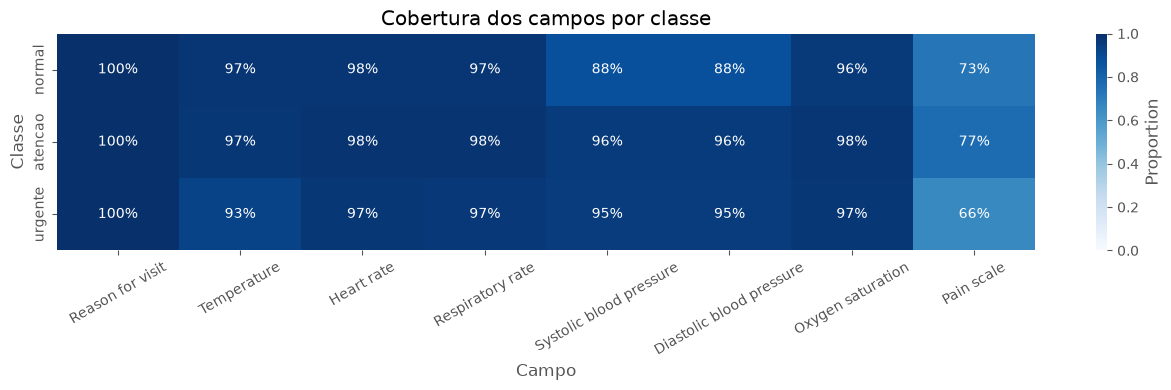

In [8]:
VITAL_RULES = {
    "TEMPF": {
        "label": "Temperature",
        "clean": "temperature_f",
        "special": {-9},
        "lower": 600,
        "upper": 1112,
        "scale": 10,
    },
    "PULSE": {
        "label": "Heart rate",
        "clean": "heart_rate",
        "special": {-9, 998},
        "lower": 0,
        "upper": 300,
        "scale": 1,
    },
    "RESPR": {
        "label": "Respiratory rate",
        "clean": "respiratory_rate",
        "special": {-9},
        "lower": 0,
        "upper": 200,
        "scale": 1,
    },
    "BPSYS": {
        "label": "Systolic blood pressure",
        "clean": "systolic_bp",
        "special": {-9},
        "lower": 0,
        "upper": 350,
        "scale": 1,
    },
    "BPDIAS": {
        "label": "Diastolic blood pressure",
        "clean": "diastolic_bp",
        "special": {-9, 998},
        "lower": 0,
        "upper": 250,
        "scale": 1,
    },
    "POPCT": {
        "label": "Oxygen saturation",
        "clean": "oxygen_saturation",
        "special": {-9},
        "lower": 0,
        "upper": 100,
        "scale": 1,
    },
    "PAINSCALE": {
        "label": "Pain scale",
        "clean": "pain_scale",
        "special": {-9, -8},
        "lower": 0,
        "upper": 10,
        "scale": 1,
    },
}

vital_audit_records = []
quality_data = eligible.copy()
for column, rule in VITAL_RULES.items():
    is_special = raw[column].isin(rule["special"])
    is_usable = ~is_special & raw[column].between(
        rule["lower"], rule["upper"]
    )
    invalid_rows = ~is_special & ~is_usable
    vital_audit_records.append(
        {
            "field": rule["label"],
            "special_rows": int(is_special.sum()),
            "usable_rows": int(is_usable.sum()),
            "invalid_rows": int(invalid_rows.sum()),
        }
    )

    clean_values = eligible[column].mask(
        eligible[column].isin(rule["special"])
    )
    clean_values = clean_values.where(
        clean_values.between(rule["lower"], rule["upper"])
    )
    quality_data[rule["clean"]] = (
        clean_values / rule["scale"]
    )

vital_audit = pd.DataFrame(vital_audit_records)
invalid_vital_rows = int(vital_audit["invalid_rows"].sum())
display(vital_audit)
assert invalid_vital_rows == 0

triage_fields = {
    "Reason for visit": "RFV1",
    **{
        rule["label"]: rule["clean"]
        for rule in VITAL_RULES.values()
    },
}
quality_data["RFV1"] = quality_data["RFV1"].where(
    quality_data["RFV1"].gt(0)
)
coverage = pd.DataFrame(
    [
        {
            "field": label,
            "available_rows": int(
                quality_data[column].notna().sum()
            ),
            "coverage": quality_data[column].notna().mean(),
        }
        for label, column in triage_fields.items()
    ]
).sort_values("coverage", ascending=False)
display(coverage.style.format({"coverage": "{:.1%}"}))

coverage_by_target = pd.DataFrame(
    {
        label: quality_data.groupby(
            "target", observed=True
        )[column].apply(lambda values: values.notna().mean())
        for label, column in triage_fields.items()
    }
)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    coverage_by_target,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot_kws={"color": "white"},
    cbar_kws={"label": "Proportion"},
    ax=ax,
)
ax.set(
    title="Cobertura dos campos por classe",
    xlabel="Campo",
    ylabel="Classe",
)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 9. Contrato temporal e prevenção de vazamento

A qualidade do dataset inclui adequação temporal. Uma coluna pode estar
preenchida e correta, mas ainda ser inválida para predição se só existir
depois da decisão de triagem.

In [9]:
ALLOWED_INPUT_FIELDS = {
    "AGE",
    "AGEDAYS",
    "SEX",
    *RFV_COLUMNS,
    "TEMPF",
    "PULSE",
    "RESPR",
    "BPSYS",
    "BPDIAS",
    "POPCT",
    "PAINSCALE",
}
EDA_ONLY_FIELDS = {
    "DIAG1",
    "DIAG2",
    "DIAG3",
    "DIAG4",
    "DIAG5",
    "ADMITHOS",
    "OBSHOS",
    "ADMIT",
    "DIEDED",
    "WAITTIME",
    "MED",
    "PROC",
}
leakage_overlap = sorted(
    ALLOWED_INPUT_FIELDS.intersection(EDA_ONLY_FIELDS)
)
missing_allowed_inputs = sorted(
    ALLOWED_INPUT_FIELDS.difference(raw.columns)
)
leakage_contract_ok = (
    not leakage_overlap and not missing_allowed_inputs
)

feature_contract = pd.DataFrame(
    [
        {
            "group": "Allowed at triage",
            "fields": ", ".join(sorted(ALLOWED_INPUT_FIELDS)),
        },
        {
            "group": "EDA only / blocked from model",
            "fields": ", ".join(sorted(EDA_ONLY_FIELDS)),
        },
    ]
)
display(feature_contract)
assert leakage_contract_ok

,group,fields
0,Allowed at triage,"AGE, AGEDAYS, BPDIAS, BPSYS, PAINSCALE, POPCT,..."
1,EDA only / blocked from model,"ADMIT, ADMITHOS, DIAG1, DIAG2, DIAG3, DIAG4, D..."


## 10. Gates de qualidade da fonte

In [10]:
gates = pd.DataFrame(
    [
        {
            "gate": "Official files match SHA-256",
            "passed": data_integrity_ok,
            "observed": f"{integrity['valid'].sum()}/2 files",
        },
        {
            "gate": "Expected raw shape",
            "passed": shape_ok,
            "observed": str(raw.shape),
        },
        {
            "gate": "Required schema",
            "passed": not missing_required_columns,
            "observed": (
                f"{len(REQUIRED_COLUMNS)} required columns"
            ),
        },
        {
            "gate": "Unique visit rows",
            "passed": (
                exact_duplicate_rows == 0
                and missing_technical_keys == 0
                and duplicated_technical_keys == 0
            ),
            "observed": "0 duplicate or missing keys",
        },
        {
            "gate": "Official source target domain",
            "passed": source_target_domain_ok,
            "observed": str(sorted(raw["IMMEDR"].unique())),
        },
        {
            "gate": "Eligible modeling cohort",
            "passed": len(eligible) == 10_495,
            "observed": f"{len(eligible):,} rows",
        },
        {
            "gate": "Three target classes",
            "passed": eligible["target"].nunique() == 3,
            "observed": ", ".join(TARGET_ORDER),
        },
        {
            "gate": "Demographic domains",
            "passed": demographic_checks["valid"].all(),
            "observed": "AGE, AGEDAYS and SEX valid",
        },
        {
            "gate": "RFV mapping and primary coverage",
            "passed": (
                unmapped_rfv_rows == 0
                and primary_rfv_coverage >= 0.95
            ),
            "observed": (
                f"{primary_rfv_coverage:.2%} RFV1 coverage"
            ),
        },
        {
            "gate": "Vital representation domains",
            "passed": invalid_vital_rows == 0,
            "observed": f"{invalid_vital_rows} invalid rows",
        },
        {
            "gate": "Temporal leakage contract",
            "passed": leakage_contract_ok,
            "observed": "No overlap",
        },
    ]
)

## 11. Materialização da coorte aprovada para EDA

Somente depois da aprovação dos gates, as transformações necessárias à
exploração são aplicadas uma vez e persistidas em SQLite. O notebook `01`
consome essa tabela e não acessa novamente o arquivo Stata.

A tabela contém diagnósticos e desfechos exclusivamente para interpretação.
Portanto, `nhamcs_2021_eda.db` **não é o futuro `training_data.db`** e não
pode ser usado diretamente para treinar o classificador.

In [11]:
def load_icd10cm_descriptions(path: Path) -> dict[str, str]:
    descriptions = {}
    with path.open(encoding="utf-8") as file_handle:
        for line in file_handle:
            diagnosis_code = line[6:13].strip()
            long_description = line[77:].strip()
            if diagnosis_code and long_description:
                descriptions[diagnosis_code] = long_description
    return descriptions


def normalize_diagnosis_code(value: object) -> str | None:
    diagnosis_code = str(value).strip().replace(".", "").rstrip("-")
    if diagnosis_code in {"", "-9", "-8", "-7"}:
        return None
    return diagnosis_code


def build_clinical_text(row: pd.Series) -> str:
    parts = []
    if row["AGE"] == 0 and 0 <= row["AGEDAYS"] <= 365:
        parts.append(f"Age: {int(row['AGEDAYS'])} days.")
    else:
        parts.append(f"Age: {int(row['AGE'])} years.")

    parts.append(f"Sex: {row['sex_label']}.")
    complaints = [
        row[f"{column}_description"]
        for column in RFV_COLUMNS
        if pd.notna(row[f"{column}_description"])
    ]
    if complaints:
        parts.append("Reasons for visit: " + "; ".join(complaints) + ".")

    observations = []
    if pd.notna(row["temperature_f"]):
        observations.append(
            f"temperature {row['temperature_f']:.1f} F"
        )
    if pd.notna(row["heart_rate"]):
        observations.append(
            f"heart rate {int(row['heart_rate'])} bpm"
        )
    if pd.notna(row["respiratory_rate"]):
        observations.append(
            f"respiratory rate {int(row['respiratory_rate'])}/min"
        )
    if pd.notna(row["systolic_bp"]) and pd.notna(
        row["diastolic_bp"]
    ):
        observations.append(
            "blood pressure "
            f"{int(row['systolic_bp'])}/{int(row['diastolic_bp'])} mmHg"
        )
    if pd.notna(row["oxygen_saturation"]):
        observations.append(
            "oxygen saturation "
            f"{int(row['oxygen_saturation'])}%"
        )
    if pd.notna(row["pain_scale"]):
        observations.append(
            f"pain score {int(row['pain_scale'])}/10"
        )
    if observations:
        parts.append(
            "Triage observations: " + "; ".join(observations) + "."
        )

    return " ".join(parts)


icd10cm_lookup = load_icd10cm_descriptions(ICD10CM_PATH)
sex_lookup = {
    int(code): label for code, label in stata_labels["SEXF"].items()
}
complaint_description_columns = [
    f"{column}_description" for column in RFV_COLUMNS
]
diagnosis_code_columns = [
    f"{column}_code" for column in DIAGNOSIS_COLUMNS
]
diagnosis_description_columns = [
    f"{column}_description" for column in DIAGNOSIS_COLUMNS
]
clean_vital_columns = [
    rule["clean"] for rule in VITAL_RULES.values()
]

eda_data = quality_data[
    [
        "IMMEDR",
        "AGE",
        "AGEDAYS",
        "SEX",
        *RFV_COLUMNS,
        *DIAGNOSIS_COLUMNS,
        *clean_vital_columns,
        "ADMITHOS",
        "OBSHOS",
        "ADMIT",
        "DIEDED",
    ]
].copy()
eda_data.insert(0, "visit_row", quality_data.index.astype(int))
eda_data["immediacy_label"] = eda_data["IMMEDR"].map(
    immediacy_lookup
)
eda_data["target"] = quality_data["target"].astype(str)
eda_data["sex_label"] = eda_data["SEX"].map(sex_lookup)

for column in RFV_COLUMNS:
    eda_data[f"{column}_description"] = eda_data[column].map(
        rfv_lookup
    )

for column in DIAGNOSIS_COLUMNS:
    normalized_codes = eda_data[column].map(
        normalize_diagnosis_code
    )
    eda_data[f"{column}_code"] = normalized_codes
    eda_data[f"{column}_description"] = normalized_codes.map(
        icd10cm_lookup
    )

eda_data["clinical_text"] = eda_data.apply(
    build_clinical_text,
    axis=1,
)
assert eda_data["clinical_text"].str.strip().ne("").all()

eda_columns = [
    "visit_row",
    "IMMEDR",
    "immediacy_label",
    "target",
    "AGE",
    "AGEDAYS",
    "SEX",
    "sex_label",
    *RFV_COLUMNS,
    *complaint_description_columns,
    *diagnosis_code_columns,
    *diagnosis_description_columns,
    *clean_vital_columns,
    "ADMITHOS",
    "OBSHOS",
    "ADMIT",
    "DIEDED",
    "clinical_text",
]
eda_data = eda_data[eda_columns]

artifact_metadata = pd.DataFrame(
    [
        {"key": "schema_version", "value": "1"},
        {"key": "dataset_version", "value": "2021"},
        {
            "key": "source_sha256",
            "value": EXPECTED_SHA256[DATA_PATH],
        },
        {"key": "row_count", "value": str(len(eda_data))},
        {
            "key": "target_order",
            "value": json.dumps(TARGET_ORDER),
        },
        {
            "key": "complaint_description_columns",
            "value": json.dumps(complaint_description_columns),
        },
        {
            "key": "usage",
            "value": "EDA only; not approved for model training",
        },
    ]
)

EDA_DATABASE_PATH.parent.mkdir(parents=True, exist_ok=True)
with sqlite3.connect(EDA_DATABASE_PATH) as connection:
    eda_data.to_sql(
        "eda_visits",
        connection,
        if_exists="replace",
        index=False,
    )
    artifact_metadata.to_sql(
        "metadata",
        connection,
        if_exists="replace",
        index=False,
    )
    persisted_rows = connection.execute(
        "SELECT COUNT(*) FROM eda_visits"
    ).fetchone()[0]
    persisted_columns = {
        row[1]
        for row in connection.execute(
            "PRAGMA table_info(eda_visits)"
        ).fetchall()
    }

artifact_ok = (
    persisted_rows == len(eda_data)
    and persisted_columns == set(eda_columns)
    and EDA_DATABASE_PATH.exists()
)
gates.loc[len(gates)] = {
    "gate": "Validated EDA artifact",
    "passed": artifact_ok,
    "observed": (
        f"{persisted_rows:,} rows and {len(persisted_columns)} columns"
    ),
}
gates["status"] = gates["passed"].map(
    {True: "PASS", False: "FAIL"}
)
display(gates[["gate", "status", "observed"]])

failed_gates = gates.loc[~gates["passed"]]
assert failed_gates.empty, (
    "Falha nos gates de qualidade: "
    + ", ".join(failed_gates["gate"])
)

print(f"Tabela materializada: {EDA_DATABASE_PATH}")
print("Tabela SQLite: eda_visits")

,gate,status,observed
0,Official files match SHA-256,PASS,2/2 files
1,Expected raw shape,PASS,"(16207, 912)"
2,Required schema,PASS,24 required columns
3,Unique visit rows,PASS,0 duplicate or missing keys
4,Official source target domain,PASS,"[np.int16(-9), np.int16(-8), np.int16(0), np.i..."
5,Eligible modeling cohort,PASS,"10,495 rows"
6,Three target classes,PASS,"normal, atencao, urgente"
7,Demographic domains,PASS,"AGE, AGEDAYS and SEX valid"
8,RFV mapping and primary coverage,PASS,99.97% RFV1 coverage
9,Vital representation domains,PASS,0 invalid rows


Tabela materializada: /Users/cassiojr/FIAP/Tech Challenge 3/data/processed/nhamcs_2021_eda.db
Tabela SQLite: eda_visits


## 12. Decisão de qualidade

In [12]:
excluded_target_rows = len(raw) - len(eligible)
display(
    Markdown(
        f"""
        ### Resultado: dados aprovados e materializados para EDA

        - **Integridade:** os dois artefatos correspondem aos hashes fixados.
        - **Volume:** {len(raw):,} linhas brutas e {len(eligible):,} linhas elegíveis.
        - **Exclusão do target:** {excluded_target_rows:,} linhas possuem estado de triagem não modelável e foram removidas explicitamente.
        - **Duplicidade:** nenhuma linha ou chave técnica duplicada foi encontrada.
        - **Motivos da visita:** todos os códigos positivos `RFV1`–`RFV5` foram resolvidos; `RFV1` cobre {primary_rfv_coverage:.2%} da coorte elegível.
        - **Ausência:** códigos sentinela foram separados de medições; ausência nunca é interpretada como valor normal.
        - **Vazamento:** diagnóstico e desfechos permanecem bloqueados como features.
        - **Contrato entre notebooks:** `{EDA_DATABASE_PATH.relative_to(PROJECT_ROOT)}` contém {len(eda_data):,} visitas aprovadas para o notebook clínico.

        O notebook `01_eda_nhamcs_2021.ipynb` utiliza somente essa tabela. Antes do treino, os gates e a preparação autorizada deverão migrar para módulos e testes do pipeline/DVC; a tabela de EDA não poderá ser usada como base de treino.
        """
    )
)


        ### Resultado: dados aprovados e materializados para EDA

        - **Integridade:** os dois artefatos correspondem aos hashes fixados.
        - **Volume:** 16,207 linhas brutas e 10,495 linhas elegíveis.
        - **Exclusão do target:** 5,712 linhas possuem estado de triagem não modelável e foram removidas explicitamente.
        - **Duplicidade:** nenhuma linha ou chave técnica duplicada foi encontrada.
        - **Motivos da visita:** todos os códigos positivos `RFV1`–`RFV5` foram resolvidos; `RFV1` cobre 99.97% da coorte elegível.
        - **Ausência:** códigos sentinela foram separados de medições; ausência nunca é interpretada como valor normal.
        - **Vazamento:** diagnóstico e desfechos permanecem bloqueados como features.
        - **Contrato entre notebooks:** `data/processed/nhamcs_2021_eda.db` contém 10,495 visitas aprovadas para o notebook clínico.

        O notebook `01_eda_nhamcs_2021.ipynb` utiliza somente essa tabela. Antes do treino, os gates e a preparação autorizada deverão migrar para módulos e testes do pipeline/DVC; a tabela de EDA não poderá ser usada como base de treino.
        